# Imports

In [4]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns

In [5]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hojjatk/mnist-dataset/train-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte


# Data Handling


In [6]:
!pip install idx2numpy
import idx2numpy
base_path = '/kaggle/input/datasets/hojjatk/mnist-dataset'

# Load the files directly
train_images = idx2numpy.convert_from_file(f'{base_path}/train-images.idx3-ubyte')
train_labels = idx2numpy.convert_from_file(f'{base_path}/train-labels.idx1-ubyte')
test_images = idx2numpy.convert_from_file(f'{base_path}/t10k-images.idx3-ubyte')
test_labels = idx2numpy.convert_from_file(f'{base_path}/t10k-labels.idx1-ubyte')

# Flatten images from 28x28 to 784
train_images = train_images.reshape(train_images.shape[0], -1)
test_images = test_images.reshape(test_images.shape[0], -1)

# Combine into one DataFrame
all_images = np.concatenate([train_images, test_images], axis=0)
all_labels = np.concatenate([train_labels, test_labels], axis=0)

df = pd.DataFrame(all_images, columns=[f'pixel{i}' for i in range(784)])
df.insert(0, 'label', all_labels)

  Preparing metadata (setup.py) ... done
  Created wheel for idx2numpy: filename=idx2numpy-1.2.3-py3-none-any.whl size=7903 sha256=f1913b8f525c77a0749ec0153d6d3eb37194dd32cfa2dbb59fa2ad47ff9331da
  Stored in directory: /root/.cache/pip/wheels/f7/48/00/ae031c97d62f39e1c3c4daa00426c09a65eb29ae5753a189ee
Successfully built idx2numpy


In [7]:
df.shape

(70000, 785)

In [8]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df[['label']].value_counts()

label
1        7877
7        7293
3        7141
2        6990
9        6958
0        6903
6        6876
8        6825
4        6824
5        6313
Name: count, dtype: int64

In [10]:
X = df.drop('label', axis=1).values
y = df['label'].values  

In [11]:
# 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=12, stratify=y
)

# split the 40% into 20% validation and 20% test (50/50 of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=12, stratify=y_temp
)

In [12]:
print(f"train: {X_train.shape}")
print(f"val:   {X_val.shape}")
print(f"test:  {X_test.shape}")

train: (42000, 784)
val:   (14000, 784)
test:  (14000, 784)


In [13]:
# convert numpy arrays to PyTorch tensors
# normalize pixel values from 0-255 to 0-1
X_train_tensor = torch.FloatTensor(X_train) / 255.0
y_train_tensor = torch.LongTensor(y_train)

X_val_tensor = torch.FloatTensor(X_val) / 255.0
y_val_tensor = torch.LongTensor(y_val)

X_test_tensor = torch.FloatTensor(X_test) / 255.0
y_test_tensor = torch.LongTensor(y_test)

In [14]:
# create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [15]:
# create DataLoaders
batch_size = 80
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

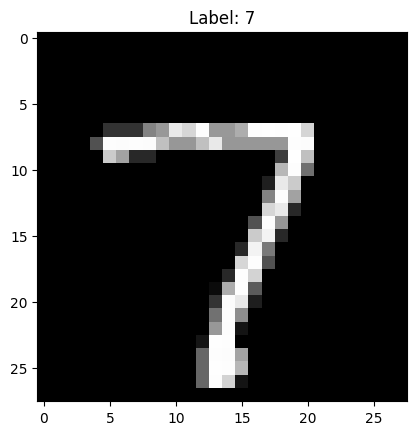

In [16]:
# test
image, label = train_dataset[512]
image_2d = image.reshape(28, 28)
plt.imshow(image_2d, cmap='gray')
plt.title(f"Label: {label.item()}")
plt.show()

# Neural Network Architecture

 The input is a flattened 28×28 image (784 pixels), and the output is 10 logits, one per digit.

```
784 → 512 → 256 → 128 → 10
```

In [17]:
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

class MNISTNet(nn.Module):
  
    def __init__(self, input_size=784, hidden_sizes=[512, 256, 128], num_classes=10):
        super(MNISTNet, self).__init__()
        layers = []
        in_features = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())
            in_features = h
        layers.append(nn.Linear(in_features, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


model = MNISTNet().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

Using device: cuda
MNISTNet(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 567,434


# Training Loop


Custom training loop using:
- **Optimizer**: SGD (Stochastic Gradient Descent)
- **Learning Rate**: 0.01
- **Loss Function**: CrossEntropyLoss
- **Epochs**: 20

In [18]:
import torch.optim as optim

def train_model(model, train_loader, val_loader,
                num_epochs=20, learning_rate=0.01):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  []
    }

    for epoch in range(1, num_epochs + 1):

        #  Training phase 
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()                      #  Clear gradients
            outputs = model(images)                    #  Forward pass
            loss    = criterion(outputs, labels)       #  Compute loss
            loss.backward()                            #  Backprop
            optimizer.step()                           #  Update weights

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc  = 100.0 * correct / total

        #  Validation phase 
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)

                val_loss_sum += loss.item() * images.size(0)
                _, predicted  = torch.max(outputs, 1)
                val_total    += labels.size(0)
                val_correct  += (predicted == labels).sum().item()

        val_loss = val_loss_sum / val_total
        val_acc  = 100.0 * val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch [{epoch:>2}/{num_epochs}]  '
                  f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  '
                  f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%')

    return history

In [19]:
# Train baseline model
NUM_EPOCHS    = 20
LEARNING_RATE = 0.01

model   = MNISTNet().to(device)
history = train_model(model, train_loader, val_loader,
                      num_epochs=NUM_EPOCHS,
                      learning_rate=LEARNING_RATE)

Epoch [ 1/20]  Train Loss: 2.2803  Train Acc: 26.64%  Val Loss: 2.2414  Val Acc: 52.64%
Epoch [ 5/20]  Train Loss: 0.4314  Train Acc: 87.67%  Val Loss: 0.4001  Val Acc: 88.32%
Epoch [10/20]  Train Loss: 0.2906  Train Acc: 91.71%  Val Loss: 0.2884  Val Acc: 91.42%
Epoch [15/20]  Train Loss: 0.2180  Train Acc: 93.76%  Val Loss: 0.2236  Val Acc: 93.46%
Epoch [20/20]  Train Loss: 0.1681  Train Acc: 95.21%  Val Loss: 0.1797  Val Acc: 94.88%


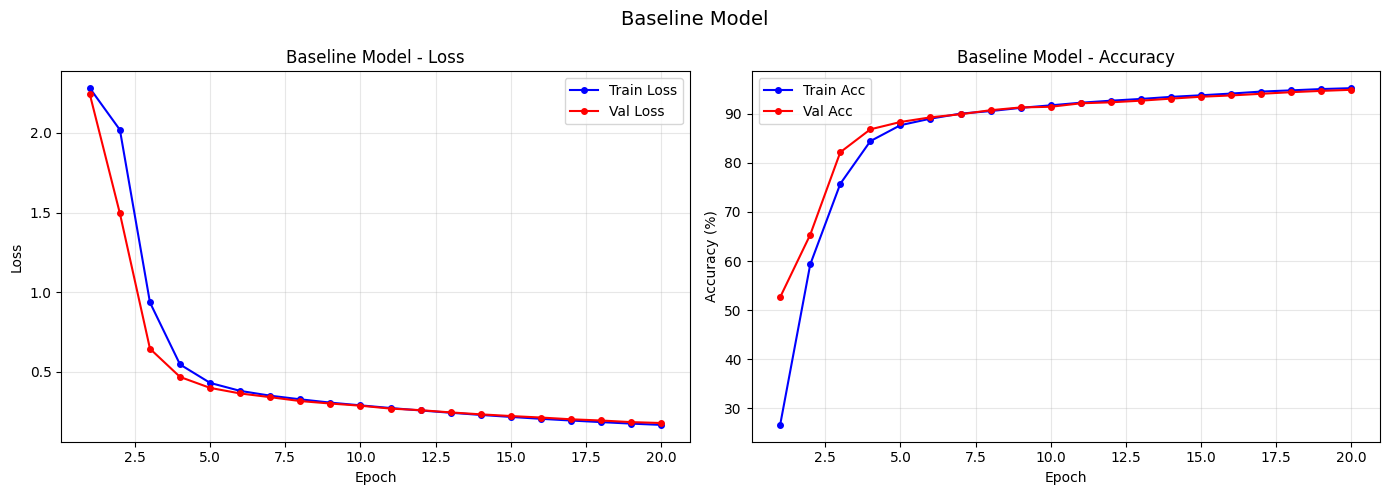

Final Train Acc : 95.21%
Final Val   Acc : 94.88%


In [20]:
def plot_history(history, title='Baseline Model'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
    axes[0].plot(epochs, history['val_loss'],   'r-o', markersize=4, label='Val Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history['train_acc'], 'b-o', markersize=4, label='Train Acc')
    axes[1].plot(epochs, history['val_acc'],   'r-o', markersize=4, label='Val Acc')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f'Final Train Acc : {history["train_acc"][-1]:.2f}%')
    print(f'Final Val   Acc : {history["val_acc"][-1]:.2f}%')


plot_history(history)

In [21]:
# Helper: train from scratch with any config and return history
def run_experiment(hidden_sizes=[512, 256, 128], learning_rate=0.01,
                   batch_size=80, num_epochs=20):
    loader_tr = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    loader_va = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    net  = MNISTNet(hidden_sizes=hidden_sizes).to(device)
    hist = train_model(net, loader_tr, loader_va,
                       num_epochs=num_epochs, learning_rate=learning_rate)
    return net, hist

# Helper: overlay multiple runs on one chart
def plot_comparison(histories, labels, title, legend_title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for i, (hist, lbl) in enumerate(zip(histories, labels)):
        epochs = range(1, len(hist['val_loss']) + 1)
        axes[0].plot(epochs, hist['val_loss'], color=colors[i], marker='o', markersize=3, label=lbl)
        axes[1].plot(epochs, hist['val_acc'],  color=colors[i], marker='o', markersize=3, label=lbl)
    for ax, ylabel in zip(axes, ['Validation Loss', 'Validation Accuracy (%)']):
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(title=legend_title)
        ax.grid(True, alpha=0.3)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

print('Helper functions ready')

Helper functions ready


## Effect of Learning Rate

The learning rate controls how big each weight update step is. Too small and the model learns painfully slowly. Too large and it overshoots and never settles.


--- lr = 0.001 ---
Epoch [ 1/20]  Train Loss: 2.3019  Train Acc: 9.25%  Val Loss: 2.2998  Val Acc: 10.74%
Epoch [ 5/20]  Train Loss: 2.2826  Train Acc: 12.70%  Val Loss: 2.2796  Val Acc: 14.56%
Epoch [10/20]  Train Loss: 2.2342  Train Acc: 41.90%  Val Loss: 2.2260  Val Acc: 42.27%
Epoch [15/20]  Train Loss: 2.0634  Train Acc: 46.94%  Val Loss: 2.0305  Val Acc: 49.10%
Epoch [20/20]  Train Loss: 1.4783  Train Acc: 65.76%  Val Loss: 1.3917  Val Acc: 67.44%

--- lr = 0.01 ---
Epoch [ 1/20]  Train Loss: 2.2775  Train Acc: 30.41%  Val Loss: 2.2309  Val Acc: 61.08%
Epoch [ 5/20]  Train Loss: 0.4213  Train Acc: 88.21%  Val Loss: 0.3899  Val Acc: 88.85%
Epoch [10/20]  Train Loss: 0.2856  Train Acc: 91.86%  Val Loss: 0.2837  Val Acc: 91.81%
Epoch [15/20]  Train Loss: 0.2145  Train Acc: 93.95%  Val Loss: 0.2218  Val Acc: 93.52%
Epoch [20/20]  Train Loss: 0.1658  Train Acc: 95.31%  Val Loss: 0.1768  Val Acc: 94.71%

--- lr = 0.05 ---
Epoch [ 1/20]  Train Loss: 1.2378  Train Acc: 63.36%  Val Loss:

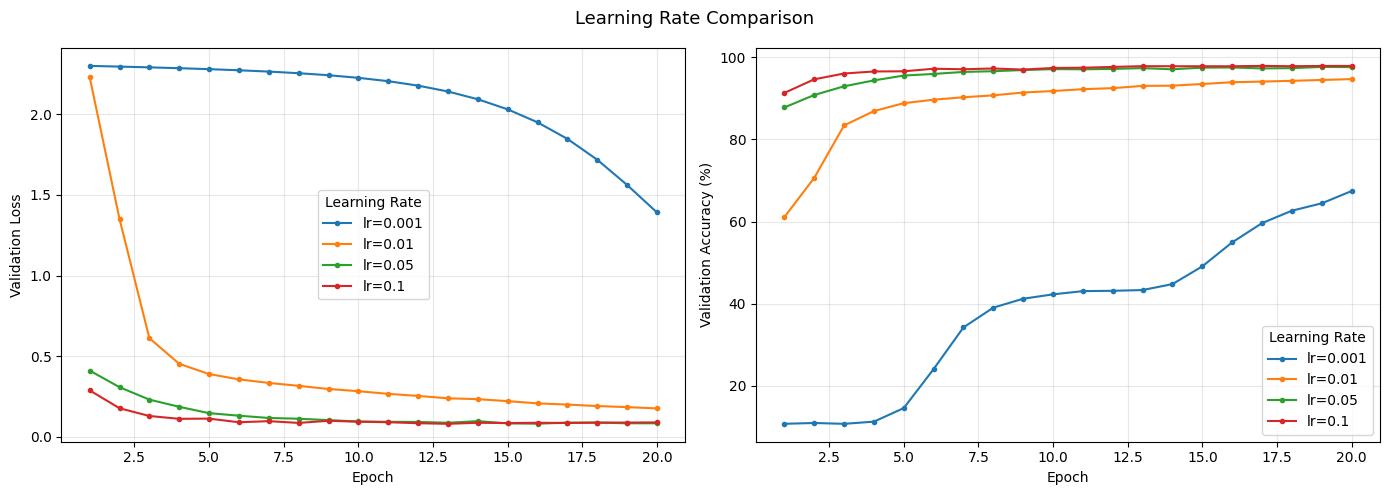


Summary:
  lr=0.001   val acc = 67.44%
  lr=0.01    val acc = 94.71%
  lr=0.05    val acc = 97.63%
  lr=0.1     val acc = 97.92%


In [22]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
lr_histories, lr_final_accs = [], []

for lr in learning_rates:
    print(f'\n--- lr = {lr} ---')
    _, hist = run_experiment(learning_rate=lr)
    lr_histories.append(hist)
    lr_final_accs.append(hist['val_acc'][-1])

plot_comparison(lr_histories, [f'lr={lr}' for lr in learning_rates],
                'Learning Rate Comparison', 'Learning Rate')

print('\nSummary:')
for lr, acc in zip(learning_rates, lr_final_accs):
    print(f'  lr={lr:<6}  val acc = {acc:.2f}%')

## Effect of Batch Size

Batch size changes how many samples the model sees before doing a weight update. Small batches = more updates per epoch, noisier gradients. Large batches = fewer updates, smoother but possibly worse generalization.


--- batch size = 16 ---
Epoch [ 1/20]  Train Loss: 1.2117  Train Acc: 65.31%  Val Loss: 0.4144  Val Acc: 88.07%
Epoch [ 5/20]  Train Loss: 0.1583  Train Acc: 95.45%  Val Loss: 0.1557  Val Acc: 95.51%
Epoch [10/20]  Train Loss: 0.0660  Train Acc: 98.14%  Val Loss: 0.1008  Val Acc: 96.97%
Epoch [15/20]  Train Loss: 0.0304  Train Acc: 99.18%  Val Loss: 0.0835  Val Acc: 97.56%
Epoch [20/20]  Train Loss: 0.0125  Train Acc: 99.76%  Val Loss: 0.0853  Val Acc: 97.64%

--- batch size = 80 ---
Epoch [ 1/20]  Train Loss: 2.2831  Train Acc: 22.73%  Val Loss: 2.2501  Val Acc: 51.79%
Epoch [ 5/20]  Train Loss: 0.4625  Train Acc: 86.90%  Val Loss: 0.4142  Val Acc: 88.14%
Epoch [10/20]  Train Loss: 0.2911  Train Acc: 91.71%  Val Loss: 0.2855  Val Acc: 91.79%
Epoch [15/20]  Train Loss: 0.2144  Train Acc: 93.97%  Val Loss: 0.2176  Val Acc: 93.60%
Epoch [20/20]  Train Loss: 0.1634  Train Acc: 95.33%  Val Loss: 0.1755  Val Acc: 94.86%

--- batch size = 256 ---
Epoch [ 1/20]  Train Loss: 2.2993  Train Acc

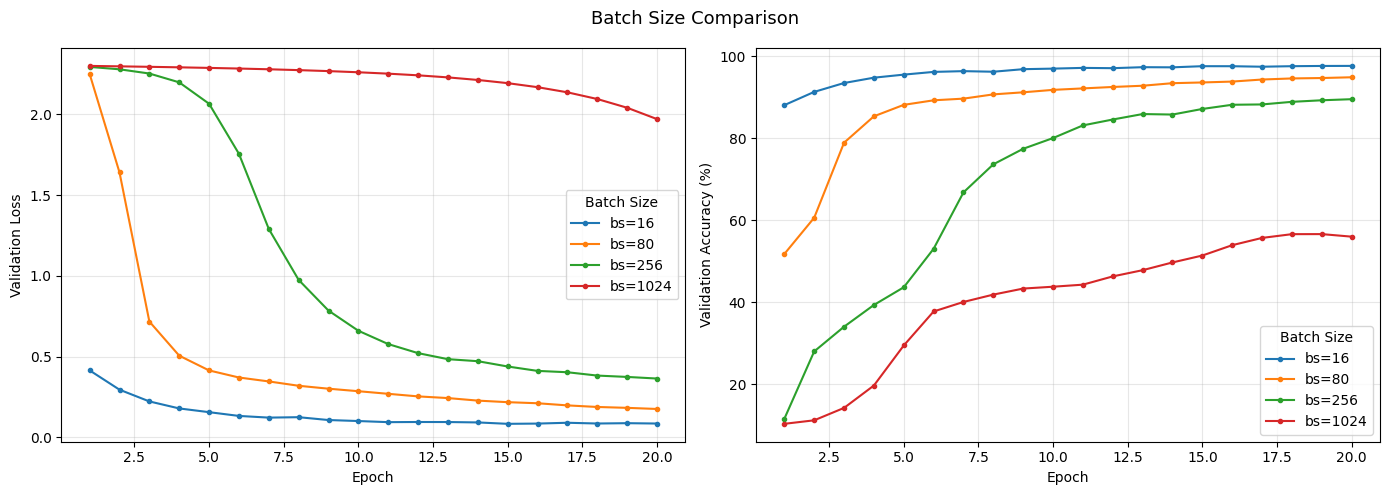


Summary:
  bs=16     val acc = 97.64%
  bs=80     val acc = 94.86%
  bs=256    val acc = 89.52%
  bs=1024   val acc = 56.02%


In [23]:
batch_sizes = [16, 80, 256, 1024]
bs_histories, bs_final_accs = [], []

for bs in batch_sizes:
    print(f'\n--- batch size = {bs} ---')
    _, hist = run_experiment(batch_size=bs)
    bs_histories.append(hist)
    bs_final_accs.append(hist['val_acc'][-1])

plot_comparison(bs_histories, [f'bs={bs}' for bs in batch_sizes],
                'Batch Size Comparison', 'Batch Size')

print('\nSummary:')
for bs, acc in zip(batch_sizes, bs_final_accs):
    print(f'  bs={bs:<5}  val acc = {acc:.2f}%')

## Effect of Architecture

Here we keep lr and batch size fixed and change the network itself both depth (number of layers) and width (neurons per layer).

The four configs we test:
| Config | Layers | Description |
|--------|--------|-------------|
| A | [128, 64] | Shallow and narrow |
| B | [512, 256, 128] | Baseline funnel |
| C | [1024, 512, 256, 128] | Deep and wide |
| D | [256, 256, 256, 256] | Uniform depth |


--- A: Shallow [128,64] ---
Epoch [ 1/20]  Train Loss: 2.1298  Train Acc: 37.67%  Val Loss: 1.7433  Val Acc: 58.89%
Epoch [ 5/20]  Train Loss: 0.4084  Train Acc: 88.50%  Val Loss: 0.3868  Val Acc: 89.05%
Epoch [10/20]  Train Loss: 0.3033  Train Acc: 91.34%  Val Loss: 0.2981  Val Acc: 91.26%
Epoch [15/20]  Train Loss: 0.2563  Train Acc: 92.67%  Val Loss: 0.2574  Val Acc: 92.39%
Epoch [20/20]  Train Loss: 0.2191  Train Acc: 93.81%  Val Loss: 0.2236  Val Acc: 93.45%

--- B: Baseline [512,256,128] ---
Epoch [ 1/20]  Train Loss: 2.2824  Train Acc: 26.55%  Val Loss: 2.2443  Val Acc: 40.19%
Epoch [ 5/20]  Train Loss: 0.4365  Train Acc: 87.57%  Val Loss: 0.4049  Val Acc: 88.39%
Epoch [10/20]  Train Loss: 0.2823  Train Acc: 91.95%  Val Loss: 0.2782  Val Acc: 91.80%
Epoch [15/20]  Train Loss: 0.2081  Train Acc: 94.08%  Val Loss: 0.2124  Val Acc: 93.72%
Epoch [20/20]  Train Loss: 0.1592  Train Acc: 95.47%  Val Loss: 0.1723  Val Acc: 94.86%

--- C: Deep+Wide [1024,512,256,128] ---
Epoch [ 1/20]  

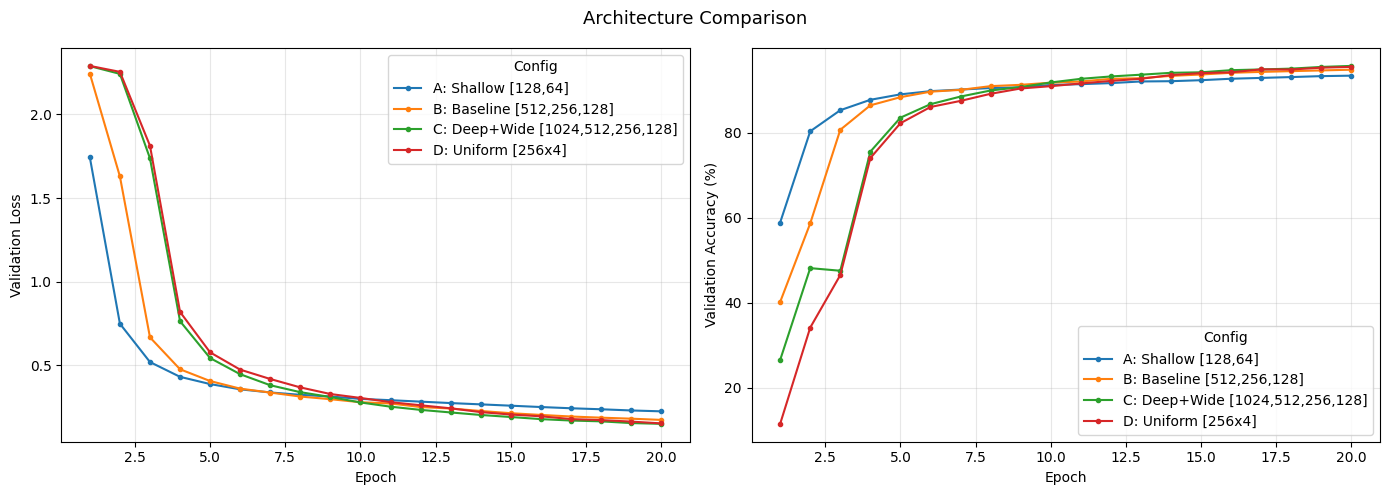


Summary:
  A: Shallow [128,64]                  val acc = 93.45%
  B: Baseline [512,256,128]            val acc = 94.86%
  C: Deep+Wide [1024,512,256,128]      val acc = 95.75%
  D: Uniform [256x4]                   val acc = 95.51%


In [24]:
architectures = [
    [128, 64],
    [512, 256, 128],
    [1024, 512, 256, 128],
    [256, 256, 256, 256],
]
arch_labels = [
    'A: Shallow [128,64]',
    'B: Baseline [512,256,128]',
    'C: Deep+Wide [1024,512,256,128]',
    'D: Uniform [256x4]',
]
arch_histories, arch_final_accs = [], []

for arch, lbl in zip(architectures, arch_labels):
    print(f'\n--- {lbl} ---')
    _, hist = run_experiment(hidden_sizes=arch)
    arch_histories.append(hist)
    arch_final_accs.append(hist['val_acc'][-1])

plot_comparison(arch_histories, arch_labels,
                'Architecture Comparison', 'Config')

print('\nSummary:')
for lbl, acc in zip(arch_labels, arch_final_accs):
    print(f'  {lbl:<35}  val acc = {acc:.2f}%')

Best learning rate : 0.1
Best batch size    : 16
Best architecture  : C: Deep+Wide [1024,512,256,128]

Training best model...
Epoch [ 1/30]  Train Loss: 0.4415  Train Acc: 85.55%  Val Loss: 0.1454  Val Acc: 95.76%
Epoch [ 5/30]  Train Loss: 0.0442  Train Acc: 98.64%  Val Loss: 0.0950  Val Acc: 97.63%
Epoch [10/30]  Train Loss: 0.0195  Train Acc: 99.35%  Val Loss: 0.0939  Val Acc: 97.68%
Epoch [15/30]  Train Loss: 0.0080  Train Acc: 99.77%  Val Loss: 0.0871  Val Acc: 98.16%
Epoch [20/30]  Train Loss: 0.0008  Train Acc: 99.98%  Val Loss: 0.0908  Val Acc: 98.42%
Epoch [25/30]  Train Loss: 0.0001  Train Acc: 100.00%  Val Loss: 0.0991  Val Acc: 98.43%
Epoch [30/30]  Train Loss: 0.0000  Train Acc: 100.00%  Val Loss: 0.1042  Val Acc: 98.42%


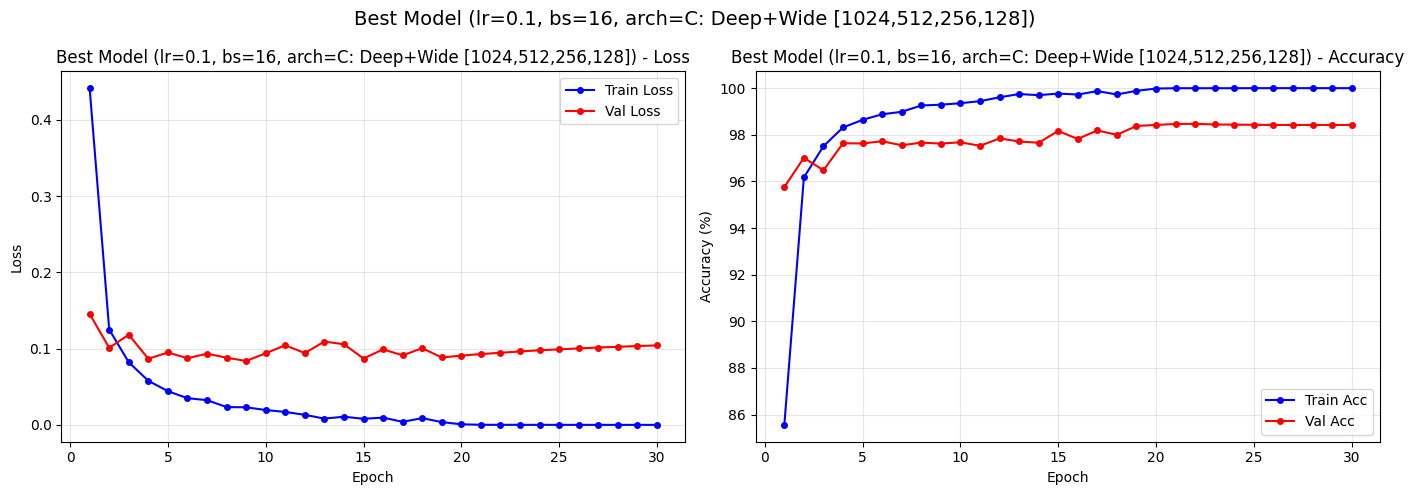

Final Train Acc : 100.00%
Final Val   Acc : 98.42%


In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

# Pick best config from each analysis
best_lr   = learning_rates[int(np.argmax(lr_final_accs))]
best_bs   = batch_sizes[int(np.argmax(bs_final_accs))]
best_arch = architectures[int(np.argmax(arch_final_accs))]
best_arch_lbl = arch_labels[int(np.argmax(arch_final_accs))]

print(f'Best learning rate : {best_lr}')
print(f'Best batch size    : {best_bs}')
print(f'Best architecture  : {best_arch_lbl}')

# Retrain with best config (30 epochs for a bit more convergence)
print('\nTraining best model...')
best_model, best_history = run_experiment(
    hidden_sizes=best_arch,
    learning_rate=best_lr,
    batch_size=best_bs,
    num_epochs=30
)

plot_history(best_history, title=f'Best Model (lr={best_lr}, bs={best_bs}, arch={best_arch_lbl})')

Test Set Accuracy: 98.46%


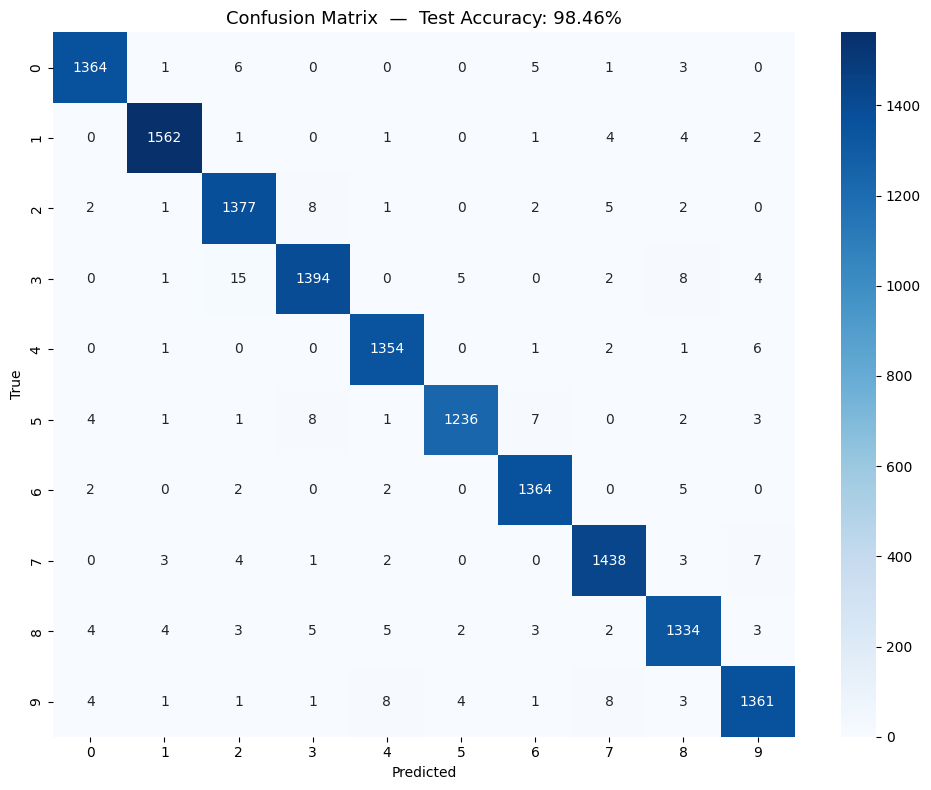


Per-class accuracy:
  Digit 0: 98.84%
  Digit 1: 99.17%
  Digit 2: 98.50%
  Digit 3: 97.55%
  Digit 4: 99.19%
  Digit 5: 97.86%
  Digit 6: 99.20%
  Digit 7: 98.63%
  Digit 8: 97.73%
  Digit 9: 97.77%


In [26]:
# Evaluate on test set
best_model.eval()
all_preds, all_labels = [], []

test_loader_best = DataLoader(test_dataset, batch_size=best_bs, shuffle=False)

with torch.no_grad():
    for imgs, lbls in test_loader_best:
        imgs = imgs.to(device)
        preds = torch.argmax(best_model(imgs), dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

test_acc = accuracy_score(y_true, y_pred) * 100
print(f'Test Set Accuracy: {test_acc:.2f}%')

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix  —  Test Accuracy: {test_acc:.2f}%', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

print('\nPer-class accuracy:')
for cls in range(10):
    cls_acc = cm[cls, cls] / cm[cls].sum() * 100
    print(f'  Digit {cls}: {cls_acc:.2f}%')

### What we see

The test accuracy is close to validation accuracy, which means the model generalizes well with no overfitting.

Looking at the confusion matrix:
- Digits **0** and **1** are almost always correct as their shapes are very distinctive.
- The most common confusions are between **8** and **3 & 5**, which makes sense visually as they share similar stroke patterns.
- Off-diagonal values are small, so even when the model is wrong, it's usually just one digit off in a reasonable way.

# CNN
---

In [27]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as funcs
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [28]:
# base CNN (no dropout, no layer norm)
class BaseCNN(nn.Module):
    def __init__(self):
        super(BaseCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.reshape(-1, 1, 28, 28)
        x = self.pool(funcs.relu(self.conv1(x)))
        x = self.pool(funcs.relu(self.conv2(x)))
        x = x.reshape(-1, 64 * 7 * 7)
        x = funcs.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [29]:
# CNN + Dropout (inherits from BaseCNN)
class DropoutCNN(BaseCNN):
    def __init__(self):
        super(DropoutCNN, self).__init__()
        self.dropout1 = nn.Dropout(0.25) 
        self.dropout2 = nn.Dropout(0.5)

    def forward(self, x):
        x = x.reshape(-1, 1, 28, 28)
        x = self.pool(funcs.relu(self.conv1(x)))
        x = self.pool(funcs.relu(self.conv2(x)))
        x = self.dropout1(x)
        x = x.reshape(-1, 64 * 7 * 7)
        x = funcs.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

In [30]:
# CNN + Layer Norm (inherits from BaseCNN)
class LayerNormCNN(BaseCNN):
    def __init__(self):
        super(LayerNormCNN, self).__init__()
        self.ln1 = nn.LayerNorm([32, 14, 14])
        self.ln2 = nn.LayerNorm([64, 7, 7])

    def forward(self, x):
        x = x.reshape(-1, 1, 28, 28)
        x = self.pool(funcs.relu(self.conv1(x)))
        x = self.ln1(x)                     
        x = self.pool(funcs.relu(self.conv2(x)))
        x = self.ln2(x)                     
        x = x.reshape(-1, 64 * 7 * 7)
        x = funcs.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [31]:
# CNN + Both (inherits from BaseCNN)
class FullCNN(BaseCNN):
    def __init__(self):
        super(FullCNN, self).__init__()
        self.ln1 = nn.LayerNorm([32, 14, 14])
        self.ln2 = nn.LayerNorm([64, 7, 7])
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)

    def forward(self, x):
        x = x.reshape(-1, 1, 28, 28)
        x = self.pool(funcs.relu(self.conv1(x)))
        x = self.ln1(x)
        x = self.pool(funcs.relu(self.conv2(x)))
        x = self.ln2(x)
        x = self.dropout1(x)
        x = x.reshape(-1, 64 * 7 * 7)
        x = funcs.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

In [32]:
models = {
    'Base CNN': BaseCNN().to(device),
    'Dropout CNN': DropoutCNN().to(device),
    'LayerNorm CNN': LayerNormCNN().to(device),
    'Full CNN': FullCNN().to(device)
}

In [33]:
all_histories = {}
for name, model in models.items():
    print(f"Training: {name}")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(20):
        # training
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        # validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        # metrics
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(train_correct / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(val_correct / val_total)
        
        print(f"Epoch [{epoch+1}/{20}] "
              f"Train Loss: {train_loss/train_total:.4f} | Train Acc: {train_correct/train_total:.4f} | "
              f"Val Loss: {val_loss/val_total:.4f} | Val Acc: {val_correct/val_total:.4f}")
    
    all_histories[name] = history

Training: Base CNN
Epoch [1/20] Train Loss: 1.6702 | Train Acc: 0.5411 | Val Loss: 0.5420 | Val Acc: 0.8486
Epoch [2/20] Train Loss: 0.4083 | Train Acc: 0.8778 | Val Loss: 0.3183 | Val Acc: 0.9015
Epoch [3/20] Train Loss: 0.2962 | Train Acc: 0.9099 | Val Loss: 0.2810 | Val Acc: 0.9145
Epoch [4/20] Train Loss: 0.2373 | Train Acc: 0.9285 | Val Loss: 0.2124 | Val Acc: 0.9361
Epoch [5/20] Train Loss: 0.1949 | Train Acc: 0.9416 | Val Loss: 0.1760 | Val Acc: 0.9461
Epoch [6/20] Train Loss: 0.1631 | Train Acc: 0.9518 | Val Loss: 0.1510 | Val Acc: 0.9556
Epoch [7/20] Train Loss: 0.1396 | Train Acc: 0.9572 | Val Loss: 0.1406 | Val Acc: 0.9570
Epoch [8/20] Train Loss: 0.1210 | Train Acc: 0.9632 | Val Loss: 0.1246 | Val Acc: 0.9645
Epoch [9/20] Train Loss: 0.1072 | Train Acc: 0.9678 | Val Loss: 0.1059 | Val Acc: 0.9679
Epoch [10/20] Train Loss: 0.0969 | Train Acc: 0.9706 | Val Loss: 0.0994 | Val Acc: 0.9702
Epoch [11/20] Train Loss: 0.0883 | Train Acc: 0.9729 | Val Loss: 0.0881 | Val Acc: 0.9738


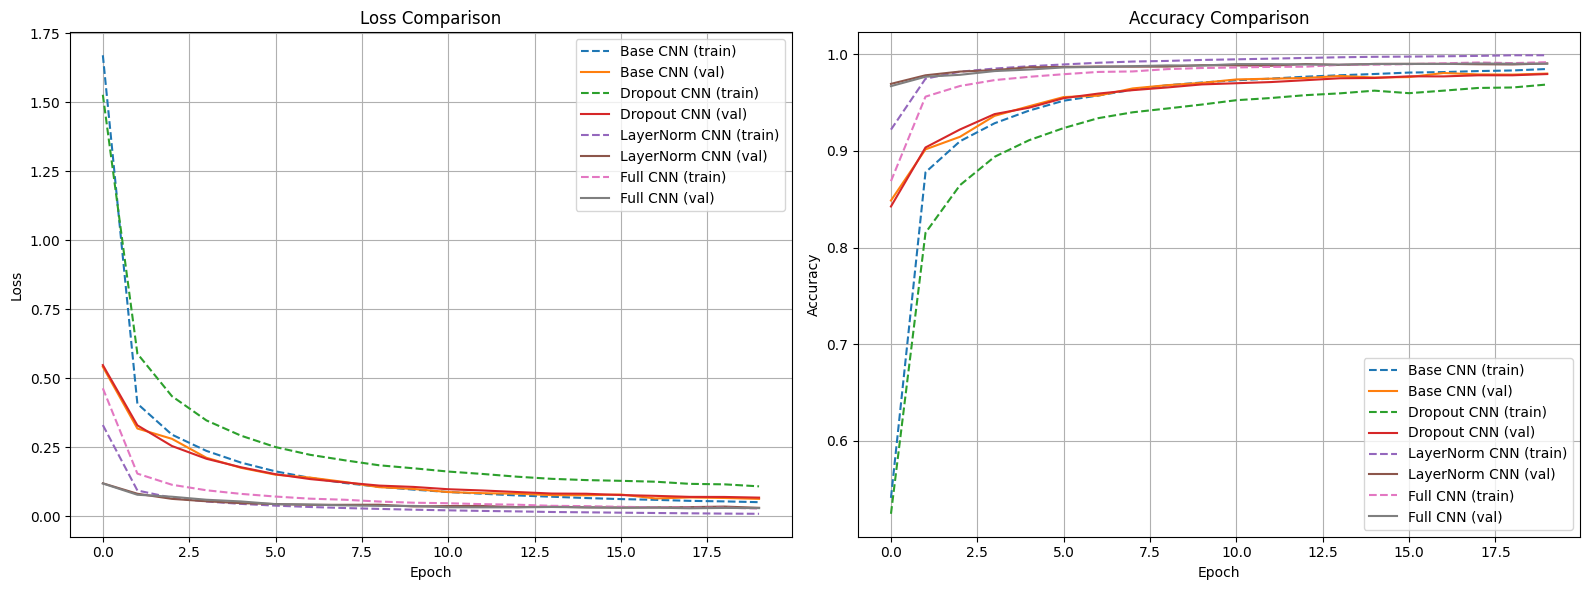


Model                 Train Acc    Val Acc
Base CNN                 0.9846     0.9799
Dropout CNN              0.9685     0.9794
LayerNorm CNN            0.9988     0.9903
Full CNN                 0.9916     0.9901


In [34]:
# plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, history in all_histories.items():
    axes[0].plot(history['train_loss'], label=f'{name} (train)', linestyle='--')
    axes[0].plot(history['val_loss'], label=f'{name} (val)')
    axes[1].plot(history['train_acc'], label=f'{name} (train)', linestyle='--')
    axes[1].plot(history['val_acc'], label=f'{name} (val)')

axes[0].set_title('Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# summary table
print(f"\n{'Model':<20} {'Train Acc':>10} {'Val Acc':>10}")
for name, history in all_histories.items():
    print(f"{name:<20} {history['train_acc'][-1]:>10.4f} {history['val_acc'][-1]:>10.4f}")

In [35]:
# testing best model
best_name = max(all_histories, key=lambda x: all_histories[x]['val_acc'][-1])
best_model = models[best_name]
print(f"\nBest Model: {best_name}")

best_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"Test Accuracy: {(all_preds == all_labels).mean():.4f}")
print(f"\nClassification Report:\n{classification_report(all_labels, all_preds)}")


Best Model: LayerNorm CNN
Test Accuracy: 0.9914

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1380
           1       0.99      1.00      0.99      1575
           2       1.00      0.99      0.99      1398
           3       0.99      0.99      0.99      1429
           4       0.99      0.99      0.99      1365
           5       1.00      0.99      0.99      1263
           6       0.99      0.99      0.99      1375
           7       0.99      0.99      0.99      1458
           8       0.99      0.99      0.99      1365
           9       0.99      0.99      0.99      1392

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



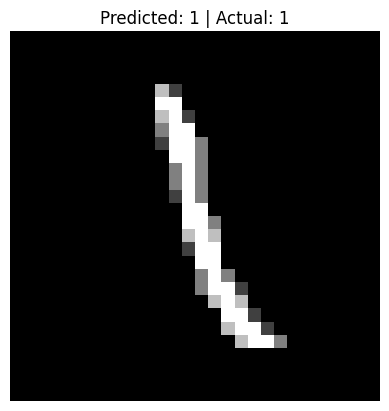

In [36]:
# sample prediction from best model
image, actual_label = test_dataset[0]
with torch.no_grad():
    output = best_model(image.unsqueeze(0).to(device))
    _, predicted = torch.max(output, 1)
plt.imshow(image.reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted.item()} | Actual: {actual_label.item()}")
plt.axis('off')
plt.show()

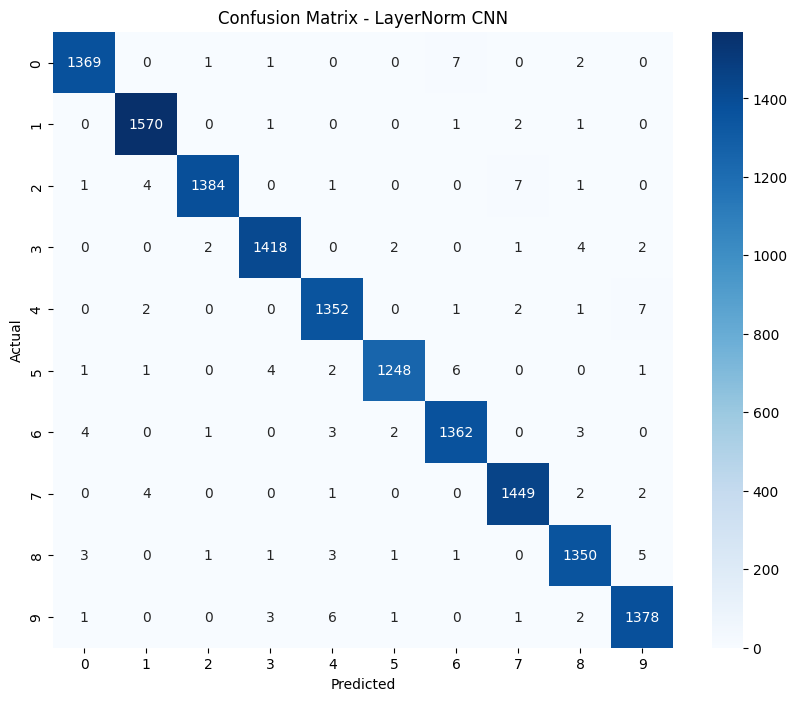

In [37]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()